In [1]:
# reload modules before execution (for the changing code in Src)
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import sqlite3
# uses the DB created in https://github.com/reebme/curated-data-sqlite
from config import DB_PATH

# uses functions from https://github.com/reebme/curated-data-sqlite
# from src/utils.py
CURATED_DATA = Path("../../Curated_Data_SQLite").resolve()
sys.path.append(str(CURATED_DATA / "src"))
import utils

import pandas as pd
import numpy as np
from itertools import combinations, product

from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [3]:
sql_folder = "../Sql/"
pic_folder = Path("../../Medium_Articles/spurious_corr_expl_pic").resolve()

In [4]:
def compute_cube_limit(points, pad=0.1):
    """
    Half-width of a symmetric plotting cube containing the points.
    """
    return np.round((1 + pad) * np.max(np.abs(points)))

In [5]:
def plot_plane_in_cube(
    ax,
    normal=(1, 1, 1),
    offset=0,
    lim=4,
    alpha=0.05,
    color=None,
    linewidth=0,
):
    """
    Plot the part of the plane

        normal[0] * x + normal[1] * y + normal[2] * z = offset

    inside the cube [-lim, lim]^3.
    """

    normal = np.asarray(normal, dtype=float)

    if np.allclose(normal, 0):
        raise ValueError("normal vector cannot be zero")

    vertices = []

    # Intersections with cube edges:
    # Fix two coordinates at cube boundaries, solve for the third.
    for i, j in combinations(range(3), 2):
        k = ({0, 1, 2} - {i, j}).pop()

        if np.isclose(normal[k], 0):
            continue

        for a, b in product([-lim, lim], repeat=2):
            p = np.zeros(3)
            p[i] = a
            p[j] = b
            p[k] = (offset - normal[i] * a - normal[j] * b) / normal[k]

            if -lim <= p[k] <= lim:
                vertices.append(p)

    if len(vertices) < 3:
        return None

    vertices = np.unique(np.round(vertices, 12), axis=0)

    if len(vertices) < 3:
        return None

    # Order vertices around their center
    center = vertices.mean(axis=0)

    # Build an orthonormal basis inside the plane
    # Pick a vector not parallel to the normal
    candidate = np.array([1.0, 0.0, 0.0])
    if np.allclose(np.cross(normal, candidate), 0):
        candidate = np.array([0.0, 1.0, 0.0])

    u = np.cross(normal, candidate)
    u = u / np.linalg.norm(u)

    v = np.cross(normal, u)
    v = v / np.linalg.norm(v)

    coords = np.column_stack([
        (vertices - center) @ u,
        (vertices - center) @ v
    ])

    angles = np.arctan2(coords[:, 1], coords[:, 0])
    vertices = vertices[np.argsort(angles)]

    return ax.plot_trisurf(
        vertices[:, 0],
        vertices[:, 1],
        vertices[:, 2],
        alpha=alpha,
        color=color,
        linewidth=linewidth,
    )

In [6]:
def add_3d_shadows(
    ax,
    x,
    y,
    z,
    lim,
    s=5,
    alpha=0.05,
    color="lightgrey",
):
    """
    Add projected shadows of a 3D point cloud onto the three cube walls.
    Assumes axes limits are [-lim, lim] in all directions.
    """

    xmin, xmax = -lim, lim
    ymin, ymax = -lim, lim
    zmin, zmax = -lim, lim

    # xy projection, onto bottom z-wall
    ax.scatter(x, y, zs=zmin, zdir="z", s=s, alpha=alpha, color=color)

    # xz projection, onto back y-wall
    ax.scatter(x, z, zs=ymax, zdir="y", s=s, alpha=alpha, color=color)

    # yz projection, onto left x-wall
    ax.scatter(y, z, zs=xmin, zdir="x", s=s, alpha=alpha, color=color)

In [7]:
def pretty_3d_axes(ax, lim, n_ticks=5):
    """
    Make a matplotlib 3D axis pretty
    """

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_zlim(-lim, lim)

    ticks = np.linspace(-lim, lim, n_ticks)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_zticks(ticks)

    ax.xaxis.label.set_color("0.4")
    ax.yaxis.label.set_color("0.4")
    ax.zaxis.label.set_color("0.4")

    ax.xaxis.pane.set_alpha(0.1)
    ax.yaxis.pane.set_alpha(0.1)
    ax.zaxis.pane.set_alpha(0.1)

    for axis in [ax.xaxis, ax.yaxis, ax.zaxis]:
        axis._axinfo["grid"]["color"] = (0.8, 0.8, 0.8, 0.25)
        axis.line.set_color((0.8, 0.8, 0.8, 0.3))

    ax.tick_params(colors="0.7")
    ax.set_box_aspect([1, 1, 1])

In [8]:
def pretty_3Dscatter_points(points,
                            pad = 0.1,
                            scatter_color='#6376bb',
                            hyperplane=None,
                            add_shadows = False,
                            azim=-30,
                            save_file=None):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(projection="3d")
    
    lim = compute_cube_limit(points, pad)
    
    x = points[0, :]
    y = points[1, :]
    z = points[2, :]
    
    # the main 3D cloud
    ax.scatter(x, y, z, s=2, alpha=0.4, color = scatter_color)

    if hyperplane is not None:
        # the hyperplane they are on
        plot_plane_in_cube(
            ax,
            normal=hyperplane,
            offset=0,
            lim=lim,
            alpha=0.05
        )

    if add_shadows:
        add_3d_shadows(ax, x, y, z, lim, s = 2)
    
    ax.set_xlabel("coordinate 1", fontsize=14)
    ax.set_ylabel("coordinate 2", fontsize=14)
    ax.set_zlabel("coordinate 3", fontsize=14)
    
    pretty_3d_axes(ax, lim)
    
    ax.view_init(elev=10, azim=azim)

    if save_file:
        plt.savefig(save_file,
                dpi=300,
                bbox_inches="tight")
        
    plt.show()

In [9]:
scatter_color = '#6376bb'

In [10]:
rng = np.random.default_rng()

# The experiment, multivariate normal n = 3 (visualization of the transformations)

In [11]:
# no of dimensions
d = 3000
# no of data points
n = 3

# n x d feature matrix
X = rng.standard_normal((n, d))

## Centering the vectors
Pearson's correlation is invariant under affine transformations (up to a sign) and fully invariant under Z-score transformations. Therefore, without loss of generality, we consider vectors sampled from the standard multivariate normal distribution:
$$
X_j \sim \mathcal N_n(0,I_n), \qquad j=1,\ldots,d.
$$

The centering below is not a preprocessing step. It is the centering that appears in the definition of Pearson's correlation.

For the j-th vector, the sample mean is:
$$ \overline{X_j} = \frac{1}{n}\sum_{i=1}^n X_{ij} $$

and sample means form a row vector:
$$
\overline{X} = \left[\overline{X_1}, \dots, \overline{X_d}\right]
$$

Then centering gives:
$$ 
\widetilde{X} = X - \mathbb{1}_n\overline{X}
$$

where n x 1

$$
\mathbf{1}_n =
\begin{bmatrix}
1 \\
\vdots \\
1 \\
\end{bmatrix}
$$

We know that sum of coordinates of a centered vector is 0:
$$
\forall j = 1\dots d: \ \sum_{i=1}^{n}\widetilde{X_{ij}}=0
$$

so every centered vector lies in the hyperplane

$$
H=\left\{z\in\mathbb{R}^n:\sum_{i=1}^{n}z_i=0\right\}
$$


In [12]:
# centering vectors required by the Pearson's correlation
tilde_X = X - X.mean(axis = 0, keepdims = True)

### Visualization of the transformation in the original coordinate system

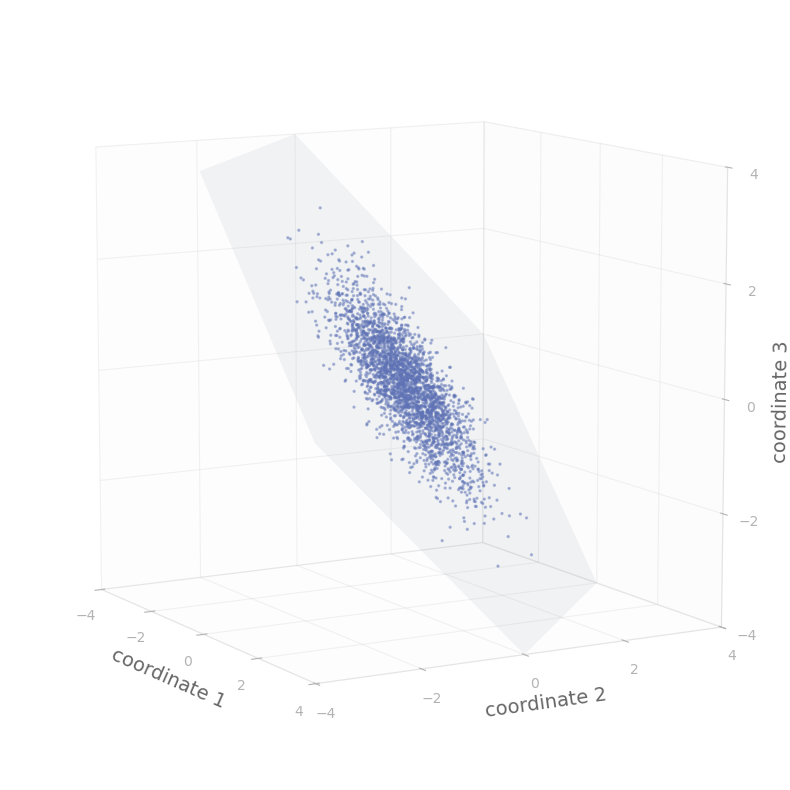

In [13]:
pretty_3Dscatter_points(tilde_X, hyperplane=np.ones(n), save_file = pic_folder / f"centered_vectors_orig_coords_{n}D.png")

In [14]:
# all centered vectors are orthogonal to the vector of ones
# and thus on the plane orthogonal to the vector of ones
np.allclose(np.ones(n) @ tilde_X, 0)

True

We know centered vectors are in the (n-1)-dim subspace, on a hyperplane orthogonal to the vector of ones.

PCA finds the sequence of orthogonal directions that capture as much variance as possible. Thus PCA finds an orthonormal basis

$$
v_1\dots v_n
$$

ordered by decreasing explained variance:

$$
\lambda_1\geq \dots \geq \lambda_n
$$

The eigendecomposition appears because the variance-maximization problem has eigenvectors as its solutions.

Since centering imposes a linear constraint:

$$
\forall j = 1\dots d: \ \mathbb{1}_n^T \ \widetilde{X_{\cdot j}} = 0
$$

all centered vectors lie in an (n−1)-dimensional subspace. Consequently, the covariance matrix has rank at most n−1, and one eigenvalue is exactly zero. Corresponding eigenvector is:

$$
v_n \propto \mathbb{1}_n
$$

(they have the same direction).

The orthonormal basis found by PCA provides a convenient coordinate system for representing and visualizing the vectors in the (n−1)-dimensional subspace. Since PCA only rotates the coordinate system, representing the data using all n−1 nonzero principal components preserves all variance.

In [15]:
pca = PCA()

hyperplane_points = pca.fit_transform(tilde_X.T)

print(np.round(pca.explained_variance_, 4))
print(np.sum(pca.explained_variance_))
print(np.round(pca.explained_variance_ratio_, 4))

[1.0069 0.9636 0.    ]
1.970506205449976
[0.511 0.489 0.   ]


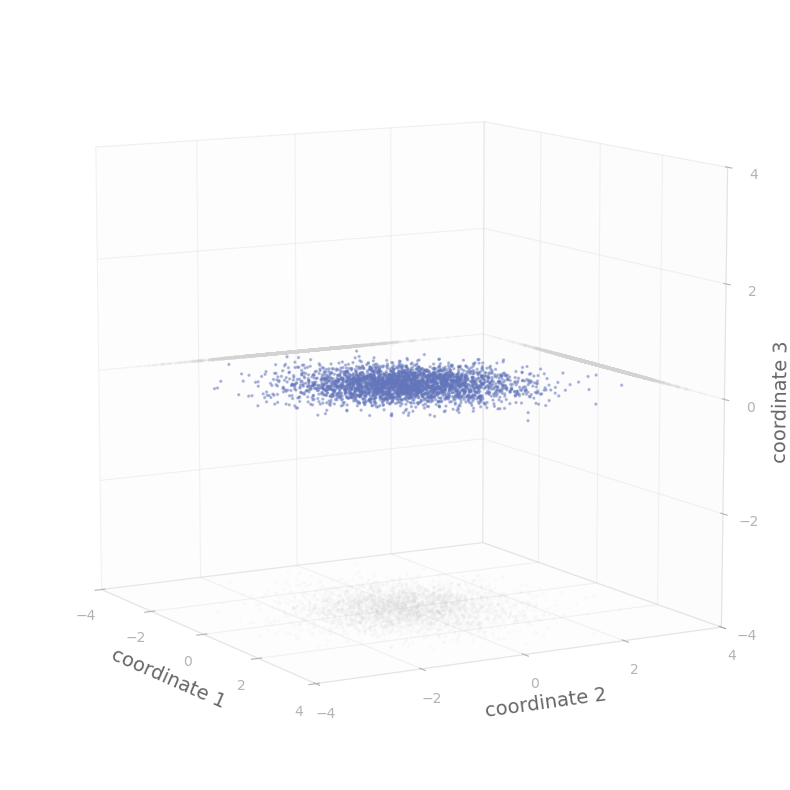

In [16]:
pretty_3Dscatter_points(hyperplane_points.T, add_shadows=True, save_file = pic_folder / f"centered_vectors_PCA_coords_{n}D.png")

## Normalizing the vectors

In [17]:
U = tilde_X / np.linalg.norm(tilde_X, axis = 0, keepdims=True)

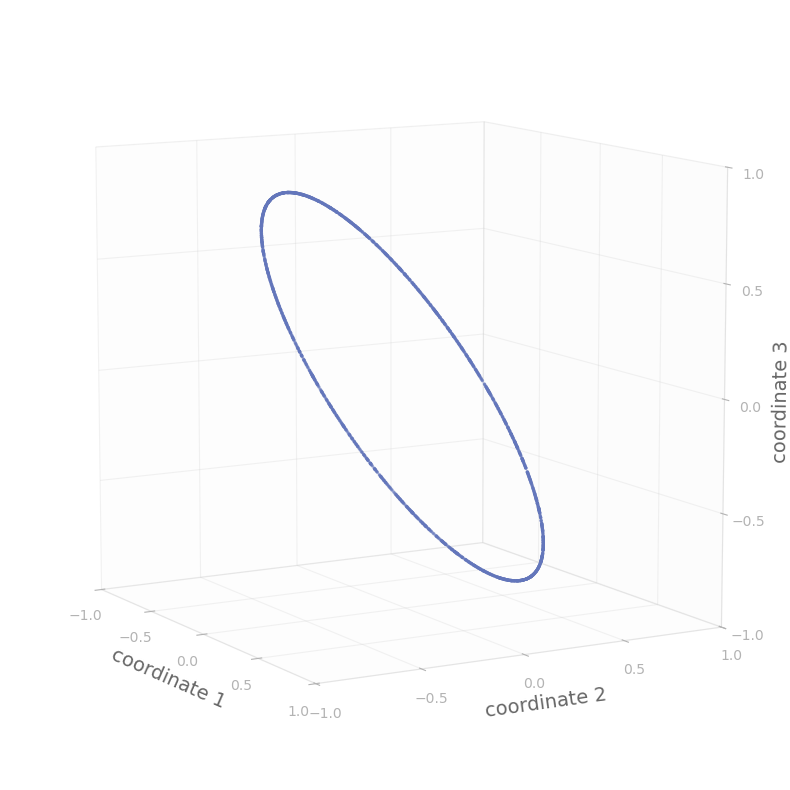

In [18]:
pretty_3Dscatter_points(U, save_file = pic_folder / f"normalized_vectors_orig_coords_{n}D.png")

In [19]:
norm_coords = pca.fit_transform(U.T)
print(np.round(pca.explained_variance_, 4))
print(np.sum(pca.explained_variance_))
print(np.round(pca.explained_variance_ratio_, 4))

[0.5085 0.4908 0.    ]
0.9992999995123351
[0.5088 0.4912 0.    ]


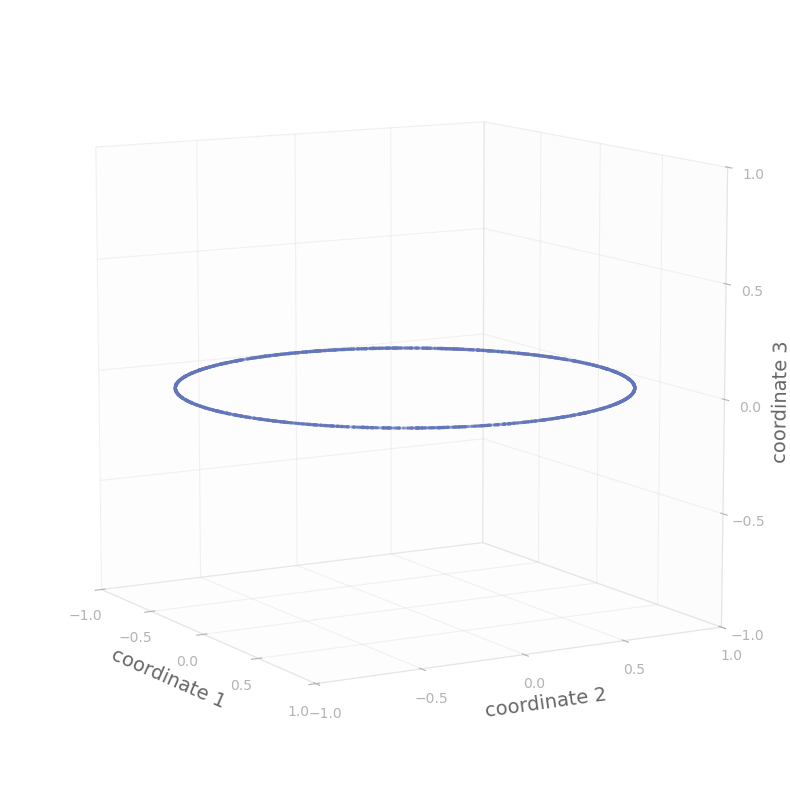

In [20]:
pretty_3Dscatter_points(norm_coords.T, save_file = pic_folder / f"normalized_vectors_PCA_coords_{n}D.png")

## Correlations

In [21]:
R = np.corrcoef(X, rowvar = False)
assert (np.round(R, 6) == np.round(U.T @ U, 6)).sum() == d**2

corrs = R[np.eye(d) != 1].ravel()

-0.8086803776651967 0.8093443267959721


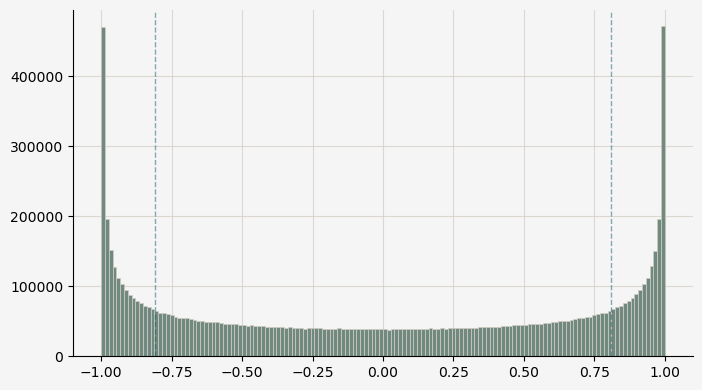

In [34]:
q20, q80 = np.quantile(corrs, [0.2, 0.8])
print(q20, q80)
utils.pretty_histogram(corrs, 
                       vertical_lines = [q20, q80],
                       save_file_name=pic_folder / f"correlations_{n}D.png")

# The experiment, multivariate normal (correlation distribution visualization)

Expected magnitude of correlations: 0.22941573387056174
Median correlation: 0.0000
Middle 50% of correlations live inside: [-0.1601, 0.1602]
50% of correlations live outside this interval.
Probability of obtaining |r| > 0.4 is 0.080742 
|r| outside 95% of mass is 0.44 


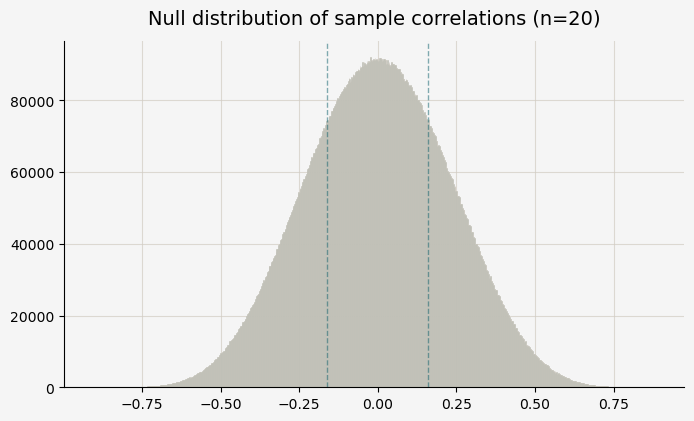

In [58]:
# no of dimensions
d = 5000
# no of data points
n = 20
assert n > 2

X = rng.standard_normal((n, d))

tilde_X = X - X.mean(axis = 0, keepdims = True)

if n < 5:
    if n == 3:
        hyperplane = np.ones(3)
    else: hyperplane = None
    pretty_3Dscatter_points(tilde_X, hyperplane=hyperplane, save_file = pic_folder / f"centered_vectors_orig_coords_{n}D.png")

pca = PCA()

hyperplane_points = pca.fit_transform(tilde_X.T)
#print(np.round(pca.explained_variance_, 4))
#print(np.sum(pca.explained_variance_))
#print(np.round(pca.explained_variance_ratio_, 4))

if n < 5:
    if n == 3:
        add_shadows = True
    else: add_shadows = False
    pretty_3Dscatter_points(hyperplane_points.T, add_shadows=add_shadows, save_file = pic_folder / f"centered_vectors_PCA_coords_{n}D.png")

U = tilde_X/np.linalg.norm(tilde_X, axis = 0, keepdims = True)

if n < 5:
    if n == 4:
        add_shadows = True
    else: add_shadows = False
    pretty_3Dscatter_points(U, add_shadows=add_shadows, save_file = pic_folder / f"normalized_vectors_orig_coords_{n}D.png")

norm_coords = pca.fit_transform(U.T)
#print(np.round(pca.explained_variance_, 4))
#print(np.sum(pca.explained_variance_))
#print(np.round(pca.explained_variance_ratio_, 4))

if n < 5:
    pretty_3Dscatter_points(norm_coords.T, pad = 1, save_file = pic_folder / f"normalized_vectors_PCA_coords_shadows_{n}D.png")

R = U.T @ U
assert (np.round(R, 6) == np.round(U.T @ U, 6)).sum() == d**2

print(f"Expected magnitude of correlations: {1/np.sqrt(n - 1)}")

corrs = R[np.eye(d) != 1].ravel()
qleft, qright, q975 = np.quantile(corrs, [0.25, 0.75, 0.975])
print(f"Median correlation: {np.median(corrs):.4f}")
print(f"Middle 50% of correlations live inside: [{qleft:.4f}, {qright:.4f}]")
print(f"50% of correlations live outside this interval.")
print(f"Probability of obtaining |r| > 0.4 is {(np.abs(corrs) > 0.4).mean():.6f} ")
print(f"|r| outside 95% of mass is {q975:.2f} ")
utils.pretty_histogram(corrs,
                       title=(f"Null distribution of sample correlations (n={n})"),
                       vertical_lines = [qleft, qright],
                       save_file_name=pic_folder / f"correlations_{n}D.png")